# Value of the data

After feature engineering: rerun the internal-only and combined models on the selected feature set, then line them up against the raw baseline (notebook 02). The gaps measure the value of feature engineering and of the purchased external scores — before and after.

In [9]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import json
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from src.data import load_selected
from src.models import oof

INTERIM = Path("../data/interim")
X, y = load_selected()
ext = [c for c in X.columns if "ext_source" in c.lower() or c.lower().startswith("ext_calc_")]
internal = [c for c in X.columns if c not in ext]

def gbm():
    return lgb.LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                              n_jobs=-1, verbose=-1)
X.shape

(307511, 441)

## After feature engineering

In [10]:
RUNS = INTERIM / "runs"; RUNS.mkdir(parents=True, exist_ok=True)
oofs = {"internal only": oof(gbm(), X[internal], y), "combined": oof(gbm(), X, y)}
eng = {}
for k, v in oofs.items():
    pd.Series(v, index=X.index, name=k).to_pickle(RUNS / f"engineered_{k.replace(' ', '_')}.pkl")
    eng[k] = roc_auc_score(y, v)
    print(f"engineered {k:14s} AUC {eng[k]:.4f}")
(INTERIM / "engineered.json").write_text(json.dumps(eng, indent=2));

engineered internal only  AUC 0.7693
engineered combined       AUC 0.7936


## Before vs after

In [11]:
base = json.loads((INTERIM / "baseline.json").read_text())
tbl = pd.DataFrame({"raw (02)": {k: base[k] for k in eng},
                    "engineered": eng})
tbl["FE gain"] = tbl["engineered"] - tbl["raw (02)"]
print(tbl.round(4), "\n")
print(f"external value  raw         {base['combined'] - base['internal only']:+.4f}")
print(f"external value  engineered  {eng['combined'] - eng['internal only']:+.4f}")
print(f"built vs bought (eng internal vs raw external)  {eng['internal only'] - base['external only']:+.4f}")

               raw (02)  engineered  FE gain
internal only    0.7025      0.7693   0.0668
combined         0.7603      0.7936   0.0334 

external value  raw         +0.0577
external value  engineered  +0.0243
built vs bought (eng internal vs raw external)  +0.0492


## Thin vs thick files

In [12]:
full, internal_p = oofs["combined"], oofs["internal only"]
thickness = X[internal].notna().sum(axis=1)
thin = (thickness < thickness.median()).to_numpy()
yv = y.to_numpy()
for label, mask in [("thin", thin), ("thick", ~thin)]:
    af, ai = roc_auc_score(yv[mask], full[mask]), roc_auc_score(yv[mask], internal_p[mask])
    print(f"{label:5s} n={int(mask.sum()):6d}   full {af:.4f}   internal {ai:.4f}   external lift {af-ai:+.4f}")

thin  n=153645   full 0.7955   internal 0.7675   external lift +0.0280
thick n=153866   full 0.7911   internal 0.7700   external lift +0.0211


## Cumulative progression — by source

Add one relational block at a time (application, + bureau, + previous_app, ... + learned) and score **built** (internal only) vs **built + bought** (internal + external). The gap between the two lines is the value of the purchased scores at that point, and it should shrink as our own data accumulates.

All raw features per step, no selection, the same untuned model, so each gap is the value of that data. Selection and tuning add a final capstone on top (the engineered headline at the top of this notebook, and nb 21). Runs on an 80k-row subsample with 3-fold OOF for speed; the shapes are robust to both.

In [13]:
from src.data import load_master
from src.progression import run_progression

def fast_gbm():
    return lgb.LGBMClassifier(n_estimators=250, learning_rate=0.05, num_leaves=31,
                              min_child_samples=50, subsample=0.8, subsample_freq=1,
                              colsample_bytree=0.7, reg_lambda=2.0, n_jobs=-1, verbose=-1)

Xm, ym = load_master()
prog = run_progression(Xm, ym, fast_gbm, axes=("source",), n=80_000)   # by table only; 80k subsample, 3-fold, 250 trees
prog.to_csv(INTERIM / "iteration_results.csv", index=False)
prog

[source   ] application                  internal 0.7007  combined 0.7548  gap +0.0541
[source   ] + bureau                     internal 0.7262  combined 0.7610  gap +0.0347
[source   ] + previous_app               internal 0.7430  combined 0.7717  gap +0.0287
[source   ] + pos_cash                   internal 0.7459  combined 0.7753  gap +0.0294
[source   ] + installments               internal 0.7535  combined 0.7796  gap +0.0261
[source   ] + credit_card                internal 0.7538  combined 0.7805  gap +0.0267
[source   ] + cross-table                internal 0.7555  combined 0.7809  gap +0.0254
[source   ] + learned                    internal 0.7565  combined 0.7797  gap +0.0232


,axis,step,n_internal,n_combined,auc_internal,auc_combined,ext_gap
0,source,application,287,309,0.7007,0.7548,0.0541
1,source,+ bureau,1773,1795,0.7262,0.7610,0.0347
2,source,+ previous_app,2349,2371,0.7430,0.7717,0.0287
3,source,+ pos_cash,2486,2508,0.7459,0.7753,0.0294
4,source,+ installments,2594,2616,0.7535,0.7796,0.0261
5,source,+ credit_card,3021,3043,0.7538,0.7805,0.0267
6,source,+ cross-table,3478,3500,0.7555,0.7809,0.0254
7,source,+ learned,3548,3570,0.7565,0.7797,0.0232


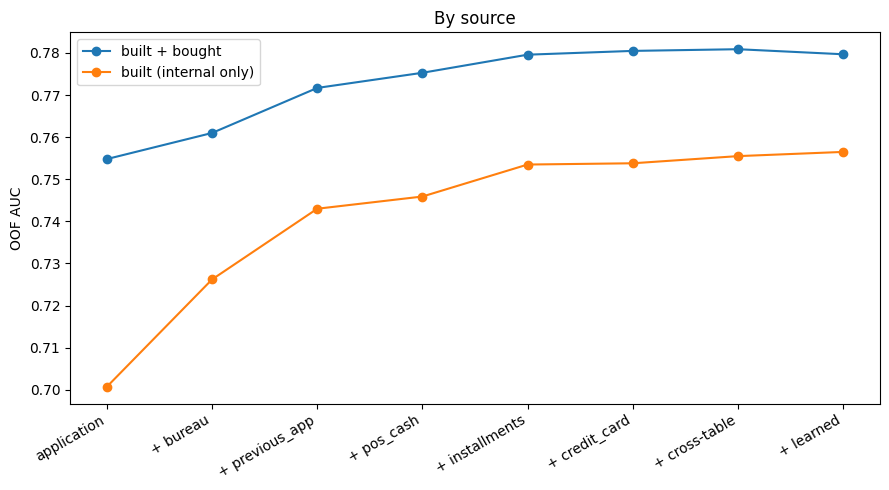

In [14]:
import matplotlib.pyplot as plt

d = prog[prog["axis"] == "source"].reset_index(drop=True)
x = range(len(d))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, d["auc_combined"], marker="o", label="built + bought")
ax.plot(x, d["auc_internal"], marker="o", label="built (internal only)")
ax.set_xticks(list(x)); ax.set_xticklabels(d["step"], rotation=30, ha="right")
ax.set_ylabel("OOF AUC"); ax.set_title("By source"); ax.legend()
plt.tight_layout(); plt.show()